In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('train_energy_data.csv')

In [3]:
df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [4]:
df.groupby('Building Type')['Energy Consumption'].mean()

Building Type
Commercial     4130.023571
Industrial     4735.142618
Residential    3681.626628
Name: Energy Consumption, dtype: float64

In [5]:
df.groupby('Day of Week')['Energy Consumption'].mean()


Day of Week
Weekday    4170.293491
Weekend    4162.096897
Name: Energy Consumption, dtype: float64

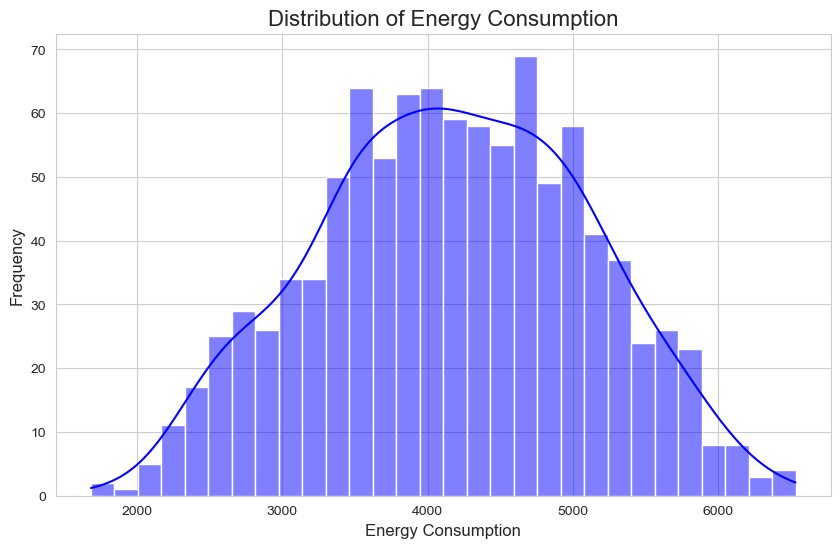

In [8]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['Energy Consumption'], kde=True, color='blue', bins=30)
plt.title('Distribution of Energy Consumption', fontsize=16)
plt.xlabel('Energy Consumption', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

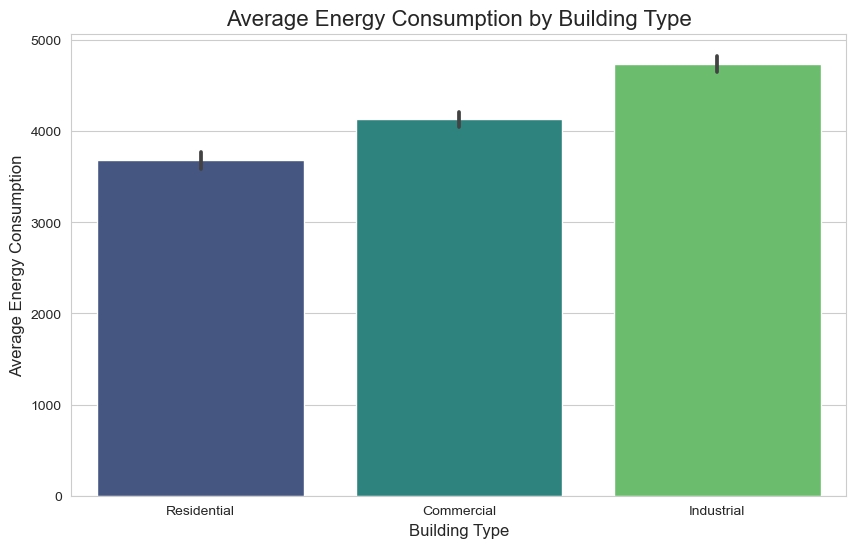

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Building Type', y='Energy Consumption', palette='viridis')
plt.title('Average Energy Consumption by Building Type', fontsize=16)
plt.xlabel('Building Type', fontsize=12)
plt.ylabel('Average Energy Consumption', fontsize=12)
plt.show()

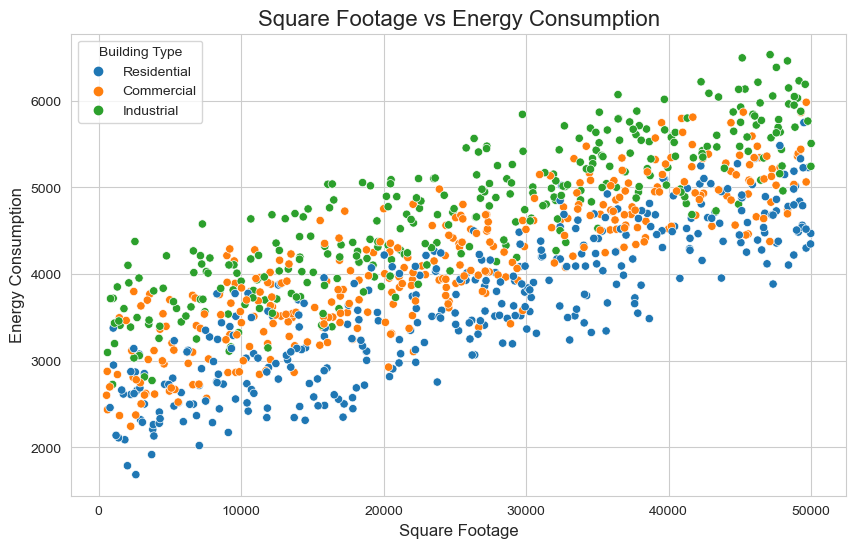

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Square Footage', y='Energy Consumption', hue='Building Type', palette='tab10')
plt.title('Square Footage vs Energy Consumption', fontsize=16)
plt.xlabel('Square Footage', fontsize=12)
plt.ylabel('Energy Consumption', fontsize=12)
plt.legend(title='Building Type')
plt.show()

C:\Users\kanis\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


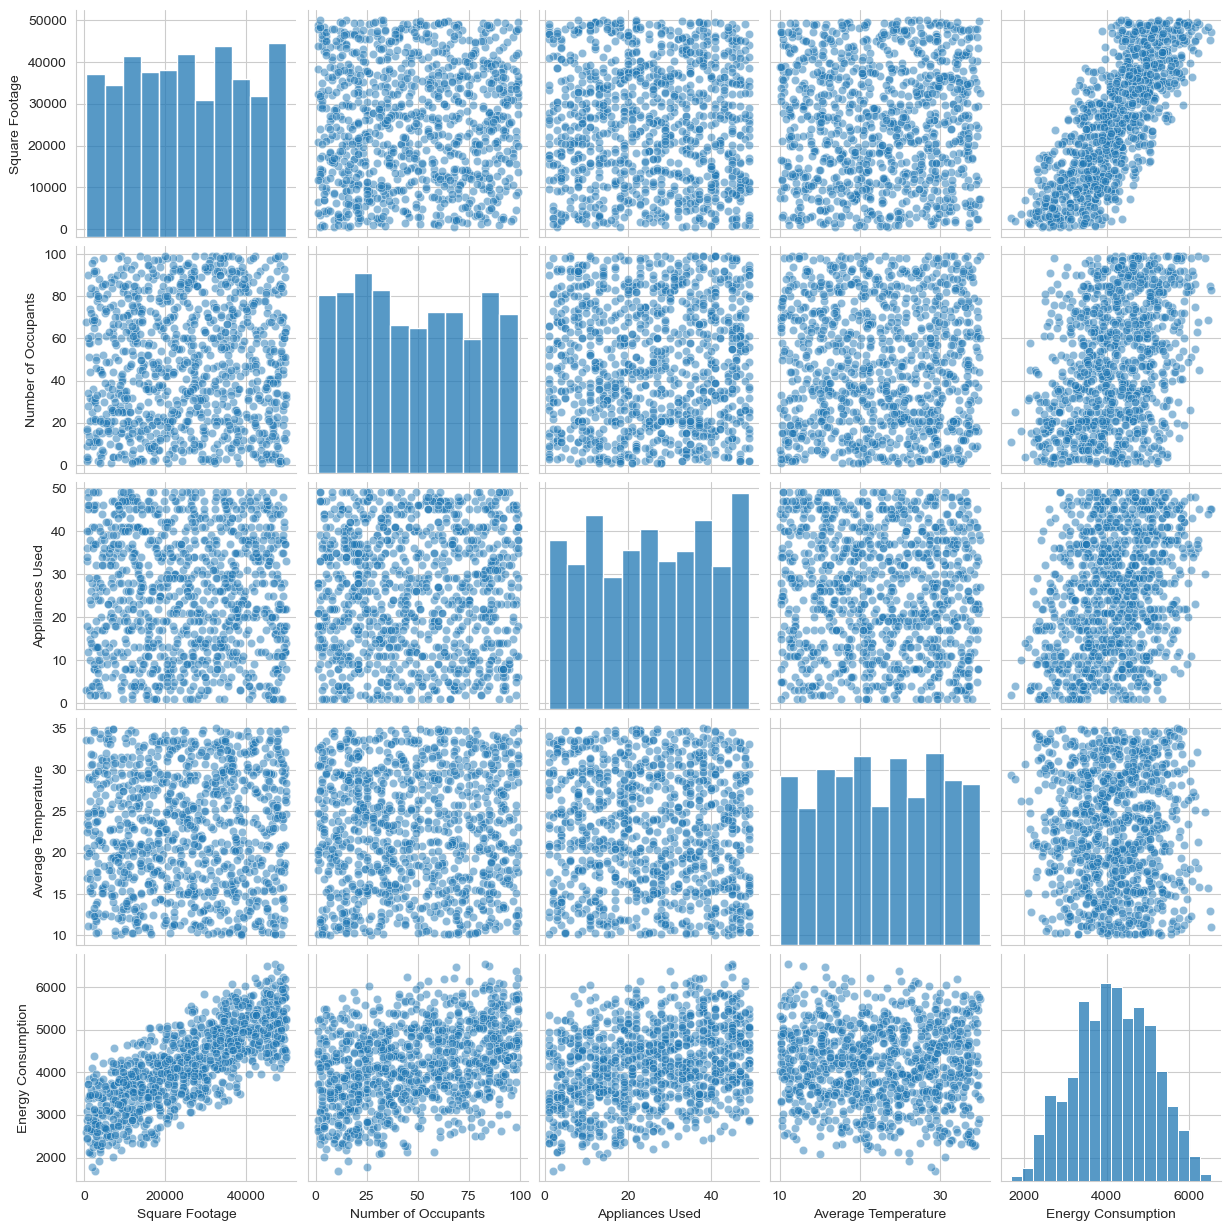

In [11]:
sns.pairplot(df, kind = 'scatter', plot_kws ={'alpha': 0.5})

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
#import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [16]:
df_encoded = pd.get_dummies(df, columns=['Building Type', 'Day of Week'], drop_first=True)

df_encoded.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,7063,76,10,29.84,2713.95,False,True,False
1,44372,66,45,16.72,5744.99,False,False,False
2,19255,37,17,14.30,4101.24,True,False,True
3,13265,14,41,32.82,3009.14,False,True,False
4,13375,26,18,11.92,3279.17,False,False,False


In [23]:

from sklearn.linear_model import LinearRegression 
lm = LinearRegression()

In [25]:
X = df_encoded.drop(columns=['Energy Consumption'])
y = df_encoded['Energy Consumption']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lm.fit(X_train,y_train)

LinearRegression()

In [26]:
lm.coef_

array([ 4.99999813e-02,  1.00000034e+01,  2.00000152e+01, -5.00011784e+00,
        5.00000028e+02, -5.00000303e+02, -5.00011032e+01])

In [27]:
cdf = pd.DataFrame(lm.coef_, X.columns , columns = ['coef'])
print(cdf)

                                 coef
Square Footage               0.050000
Number of Occupants         10.000003
Appliances Used             20.000015
Average Temperature         -5.000118
Building Type_Industrial   500.000028
Building Type_Residential -500.000303
Day of Week_Weekend        -50.001103


<Axes: ylabel='Energy Consumption'>

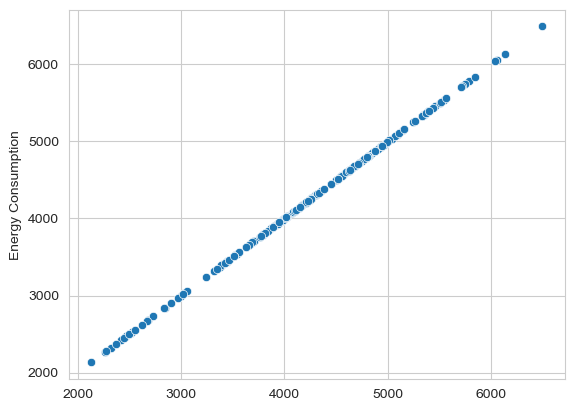

In [29]:
predictions = lm.predict(X_test)
sns.scatterplot(x= predictions , y = y_test)

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [31]:
print('Mean Absolute_Error : ' , mean_absolute_error(y_test, predictions))
print('Mean Squared Error : ' , mean_squared_error(y_test, predictions))
print('RMSE : ' , math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute_Error :  0.011412201062660188
Mean Squared Error :  0.0001885508552748998
RMSE :  0.013731382132724287


C:\Users\kanis\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\kanis\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


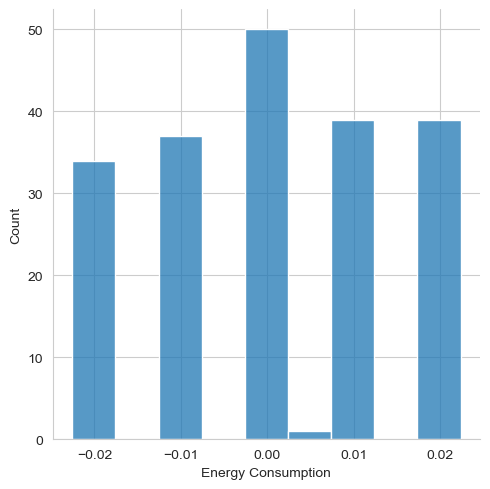

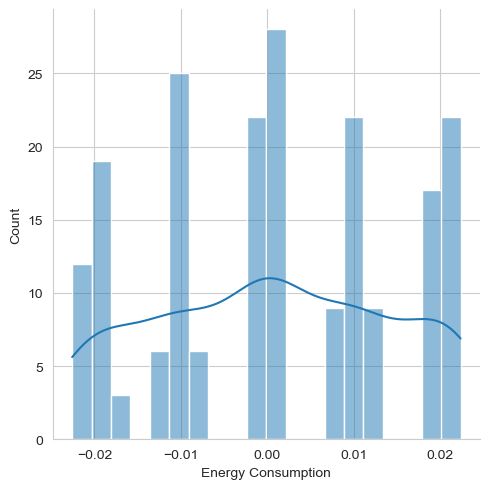

In [34]:
Residuals = y_test - predictions
sns.displot(Residuals )
sns.displot(Residuals , bins = 20 , kde = True)

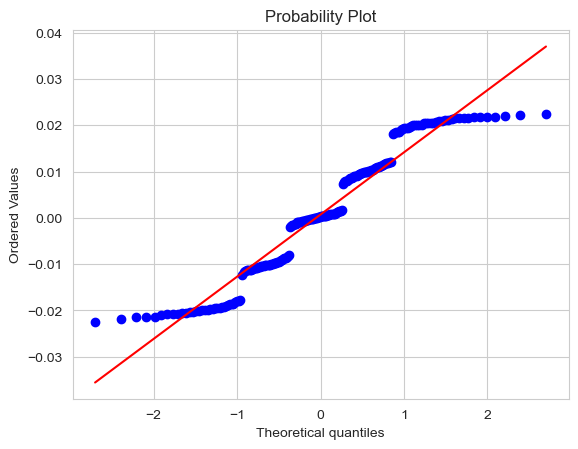

In [36]:
import pylab
import scipy.stats as stats
stats.probplot(Residuals , dist = "norm" , plot = pylab)
pylab.show()